<a href="https://colab.research.google.com/github/HiyoriVn/CSE_Machine-Learning/blob/main/BTVN_underfit_overfit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

np.random.seed(302)

In [2]:
# Training set: Gio on tap (0-10h) -> Diem thi (0-10 diem), dang loi suat giam dan
n_samples = 30
x_train = np.sort(np.random.rand(n_samples, 1) * 10, axis=0)
y_train = (10 * (1 - np.exp(-x_train / 2))).ravel() + np.random.normal(0, 0.5, n_samples)

# Testing set
x_test = np.linspace(0, 10, 200)[:, np.newaxis]
y_test = (10 * (1 - np.exp(-x_test / 2))).ravel()

# Overfitting
DEGREE_OVERFIT = 15    #% Settings
overfit_model = make_pipeline(PolynomialFeatures(degree=DEGREE_OVERFIT), LinearRegression())
overfit_model.fit(x_train, y_train)

# MSE
train_err = mean_squared_error(y_train, overfit_model.predict(x_train))
test_err = mean_squared_error(y_test, overfit_model.predict(x_test))

print(f"--- Degree: {DEGREE_OVERFIT} ---")
print(f"Train MSE: {train_err:.4f}")
print(f"Test MSE : {test_err:.4f}")


--- Degree: 15 ---
Train MSE: 0.3896
Test MSE : 15380.3438


In [3]:
# K-fold Cross-Validation
k = 4     #% Settings
kf = KFold(n_splits=k, shuffle=True, random_state=302)

candidate_degrees = list(range(1, n_samples - 1))
cv_errors = []

for deg in candidate_degrees:
    fold_errors = []

    for train_idx, val_idx in kf.split(x_train):
        x_tr_fold, y_tr_fold = x_train[train_idx], y_train[train_idx]
        x_val_fold, y_val_fold = x_train[val_idx], y_train[val_idx]

        model_fold = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression())
        model_fold.fit(x_tr_fold, y_tr_fold)
        val_pred = model_fold.predict(x_val_fold)

        fold_errors.append(mean_squared_error(y_val_fold, val_pred))

    cv_errors.append(np.mean(fold_errors))  ## Note: Kfold mean validation error

# Find best degree (smallest CV error)
best_degree = candidate_degrees[np.argmin(cv_errors)]
print(f"\nBest degree: {best_degree}")

# Re-Training
fixed_model = make_pipeline(PolynomialFeatures(degree=best_degree), LinearRegression())
fixed_model.fit(x_train, y_train)
fixed_test_err = mean_squared_error(y_test, fixed_model.predict(x_test))

print(f"MSE (Degree = {best_degree}): {fixed_test_err:.4f}")



Best degree: 3
MSE (Degree = 3): 0.0817


Visualization (sap xep theo thu tu Diem thi tang dan) & Predicting

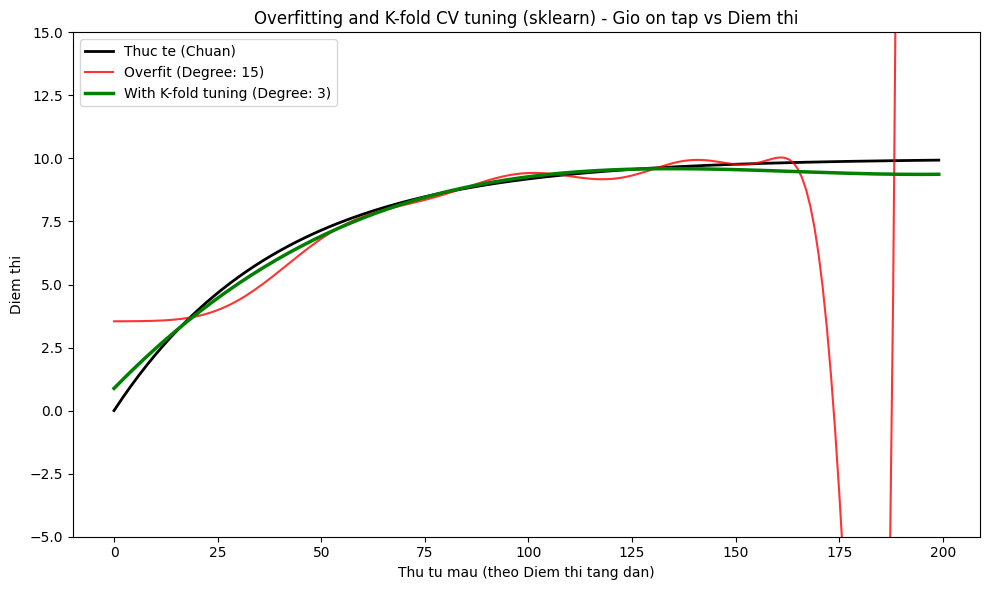

In [4]:
# Sap xep theo gia tri thuc te tang dan
order = np.argsort(y_test)
y_test_sorted = y_test[order]
x_test_sorted = x_test[order]

pred_overfit_sorted = overfit_model.predict(x_test_sorted)
pred_fixed_sorted = fixed_model.predict(x_test_sorted)

idx_axis = np.arange(len(y_test_sorted))

plt.figure(figsize=(10, 6))
plt.plot(idx_axis, y_test_sorted, color='black', linewidth=2, label='Thuc te (Chuan)')
plt.plot(idx_axis, pred_overfit_sorted, color='red', linewidth=1.5, alpha=0.8, label=f'Overfit (Degree: {DEGREE_OVERFIT})')
plt.plot(idx_axis, pred_fixed_sorted, color='green', linewidth=2.5, label=f'With K-fold tuning (Degree: {best_degree})')

plt.xlabel("Thu tu mau (theo Diem thi tang dan)")
plt.ylabel("Diem thi")
plt.title("Overfitting and K-fold CV tuning (sklearn) - Gio on tap vs Diem thi")
plt.legend()
plt.ylim(-5, 15)
plt.tight_layout()
plt.show()


In [ ]:
# Prediction test
a = float(input("Input x (gio on tap): "))

x_new = np.array([[a]])

y_pred = fixed_model.predict(x_new)
y_overfit_pred = overfit_model.predict(x_new)
y_real = 10 * (1 - np.exp(-a / 2))

print(f"Predicted value from the overfit model at x = {a}: {y_overfit_pred[0]:.4f}  [{(y_overfit_pred[0] - y_real):.4f}]")
print(f"Predicted value from the fixed model at x = {a}: {y_pred[0]:.4f}  [{(y_pred[0] - y_real):.4f}]")
print(f"Expected value at x = {a}: {y_real:.4f}")
